In [1]:
# import
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from scipy.stats import sem, pearsonr, zscore, ttest_1samp, ttest_ind
import pandas as pd
from sklearn.linear_model import Ridge, RidgeCV
import pickle
import pandas as pd
import matplotlib.image as mpimg

import sys
sys.path.append('../util_code')

from functions import neuron_reliability, reliability_filtering_tb, reliability_filtering, convert_to_deg, regression_indices, model_reliability_2, check_normality

Figure 3 A

In [2]:
# load neural data for Pico
p_file_s5 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')
p_file_s3 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
p_file_s4 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')

p_rates_s5 = p_file_s5['/psth'][:]
p_rates_s3 = p_file_s3['/psth'][:]
p_rates_s4 = p_file_s4['/psth'][:]

In [3]:
# determine which ones are reliable neurons
s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))
p_rel = neuron_reliability(s5_neural_pico)[0]

/tmp/ipykernel_1170325/747912026.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))


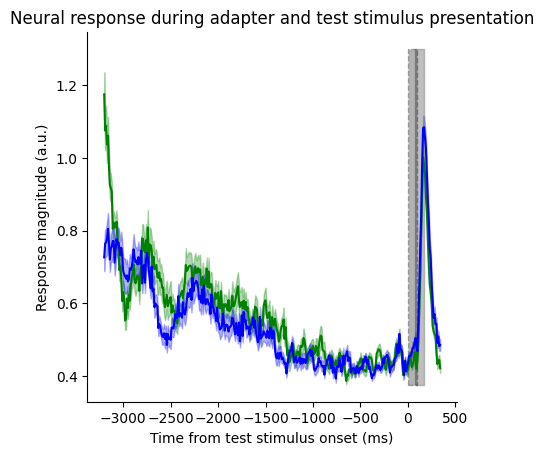

In [4]:
# plot the change in neural response over time 
plt_s3 = reliability_filtering_tb(p_rates_s3,p_rel,metric=0.2)
plt_s4 = reliability_filtering_tb(p_rates_s4,p_rel,metric=0.2)

plt_s3 = np.nanmean(np.nanmean(plt_s3[:,:,10:,:],axis=3),axis=1)
plt_s4 = np.nanmean(np.nanmean(plt_s4[:,:,10:,:],axis=3),axis=1)

# plot the average across images and with error of sem across images
t = range(-3200,350,10) # the full range of the data 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.plot(t,np.nanmean(plt_s3[:,:355],axis=0),color='green') # rightward adapter
plt.fill_between(t,y1=np.nanmean(plt_s3[:,:355],axis=0)-sem(plt_s3[:,:355],axis=0),y2=np.nanmean(plt_s3[:,:355],axis=0)+sem(plt_s3[:,:355],axis=0),color='green',alpha=0.3)

plt.plot(t,np.nanmean(plt_s4[:,:355],axis=0),color='blue') # leftward adapter
plt.fill_between(t,y1=np.nanmean(plt_s4[:,:355],axis=0)-sem(plt_s4[:,:355],axis=0),y2=np.nanmean(plt_s4[:,:355],axis=0)+sem(plt_s4[:,:355],axis=0),color='blue',alpha=0.3)

toi = Rectangle((70,0.375),width=100,height=1.3-0.375,color='grey',alpha=0.5) # the time we are interested in
plt.gca().add_patch(toi)

im_pres = Rectangle((0,0.375),width=100,height=1.3-0.375,color='black',linestyle='--',alpha=0.3) # image presentation
plt.gca().add_patch(im_pres)

plt.xlabel('Time from test stimulus onset (ms)')
plt.ylabel('Response magnitude (a.u.)')
plt.title('Neural response during adapter and test stimulus presentation')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# save the plot
# plt.savefig('/home/eyakub/scratch/neural_timeseries.eps', format='eps', bbox_inches='tight')

Figure 3 B

In [5]:
# load the neural data
p_file_s5 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')
k_file_s5 = h5py.File('../data/neural/m2_season5.mat','r')

p_file_s3 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
k_file_s3 = h5py.File('../data/neural/m2_season3.mat','r')

p_file_s4 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')
k_file_s4 = h5py.File('../data/neural/m2_season4.mat','r')

p_rates_s5 = p_file_s5['/psth'][:]
k_rates_s5 = k_file_s5['/rates'][:]

p_rates_s3 = p_file_s3['/psth'][:]
k_rates_s3 = k_file_s3['/kenny_s3'][:]

p_rates_s4 = p_file_s4['/psth'][:]
k_rates_s4 = k_file_s4['/kenny_s4'][:]

In [6]:
# getting 70-170 ms for s5 (no motion adaptation)
s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))
s5_neural_kenny = k_rates_s5

# concatenate Pico and Kenny's data
s5_neural = np.concatenate((s5_neural_pico,s5_neural_kenny),axis=1)

# get the neuron reliabilities for 70-170 ms
rel, std_rel = neuron_reliability(s5_neural)

# filter neurons to include only those with r > 0.2
s5_neural = reliability_filtering(s5_neural,rel,metric=0.2)

# get the standard deviation for each neuron and each image across trials 
s5_neural_mean = np.nanmean(s5_neural,axis=2)
s5_neural_std = np.nanstd(s5_neural,axis=2)

/tmp/ipykernel_1170325/130633690.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_pico = np.transpose(np.nanmean(p_rates_s5[:,:,7:17,:],axis=2), (0,2,1))


In [7]:
# getting 70-170 ms for s3 (right) and s4 (left)
s3_neural_pico = np.transpose(np.nanmean(p_rates_s3[:,:,337:347,:],axis=2), (0,2,1)) 
s4_neural_pico = np.transpose(np.nanmean(p_rates_s4[:,:,337:347,:],axis=2), (0,2,1))
s3_neural_kenny = k_rates_s3
s4_neural_kenny = k_rates_s4

# concatenate the data from Pico and Kenny
s3_neural = np.concatenate((s3_neural_pico,s3_neural_kenny), axis=1)
s4_neural = np.concatenate((s4_neural_pico,s4_neural_kenny), axis=1)

# filtering such that only neurons with r > 0.2 are left for S3 and S4
s3_neural = reliability_filtering(s3_neural,rel,metric=0.2)
s4_neural = reliability_filtering(s4_neural,rel,metric=0.2)

# get the standard deviation across trials
s3_neural_mean = np.nanmean(s3_neural,axis=2)
s4_neural_mean = np.nanmean(s4_neural,axis=2)
s3_neural_std = np.nanstd(s3_neural,axis=2)
s4_neural_std = np.nanstd(s4_neural,axis=2)

In [8]:
# getting the reliability of the included neurons for their season, no spearman-brown correction
s5_rels = neuron_reliability(s5_neural,sb_correct=False)[0]
s3_rels = neuron_reliability(s3_neural,sb_correct=False)[0]
s4_rels = neuron_reliability(s4_neural,sb_correct=False)[0]

In [9]:
# define a function to do subsampled correlation 
def sub_samp_corr(data1,data2,data1_rel,data2_rel,runs=20):
    '''
    data1 and data2 = [n_img,n_trials]
    '''
    emp = np.empty(20)
    emp_corr = np.empty(20)
    for x in range(runs):
        rng1 = np.random.default_rng(seed=x)
        rng2 = np.random.default_rng(seed=2*(x+1))
        random_indices_1 = rng1.choice(data1.shape[1], size=int(data1.shape[1]/2), replace=False)
        random_indices_2 = rng2.choice(data2.shape[1], size=int(data2.shape[1]/2), replace=False)
        data1_sub = np.nanmean(data1[:,random_indices_1],axis=1)
        data2_sub = np.nanmean(data2[:,random_indices_2],axis=1)
        R = pearsonr(data1_sub,data2_sub)[0]
        emp[x]= R
        emp_corr[x] = R/((data1_rel*data2_rel)**0.5)
    return [np.nanmean(emp),np.nanmean(emp_corr),np.nanstd(emp_corr)]

In [10]:
# get the correlations between responses before motion adaptation and after rightward (s3) or leftward (s4) motion adaptation 
# for all reliable neurons
s3_s5 = []
s4_s5 = []

s3_s5_plain = []
s3_s5_std_plain = []
s4_s5_plain = []
s4_s5_std_plain = []

s3_s5_uncorr = []
s4_s5_uncorr = []

for i in range(s5_neural.shape[1]):
    s5t = np.squeeze(s5_neural[:,i,:])
    s3t = np.squeeze(s3_neural[:,i,:])
    s4t = np.squeeze(s4_neural[:,i,:])
    
    s53_r, s53_r_corr, s53_r_std = sub_samp_corr(s5t,s3t,s5_rels[i],s3_rels[i])
    s3_s5.append({'idx':i,'r':s53_r_corr,'std':s53_r_std})
    s3_s5_uncorr.append({'idx':i,'r':s53_r})
    
    s3_s5_plain.append(s53_r_corr)
    s3_s5_std_plain.append(s53_r_std)
    
    s54_r, s54_r_corr, s54_r_std = sub_samp_corr(s5t,s4t,s5_rels[i],s4_rels[i])
    s4_s5.append({'idx':i,'r':s54_r_corr,'std':s54_r_std})
    s4_s5_uncorr.append({'idx':i,'r':s54_r})
    
    s4_s5_plain.append(s54_r_corr)
    s4_s5_std_plain.append(s54_r_std)

/tmp/ipykernel_1170325/1822782760.py:17: RuntimeWarning: invalid value encountered in scalar power
  emp_corr[x] = R/((data1_rel*data2_rel)**0.5)
/tmp/ipykernel_1170325/1822782760.py:18: RuntimeWarning: Mean of empty slice
  return [np.nanmean(emp),np.nanmean(emp_corr),np.nanstd(emp_corr)]
/home/eyakub/scratch/.obj_pos_venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [11]:
# sort the correlations 

# helper function to sort by the entry in 'r'
def helper(e):
  return e['r']
    
s3_s5_sorted = sorted(s3_s5,key=helper)

# sort R(S4,S5) based on the indices in s3_s5_sorted

# get the order of 'idx' values from the sorted s3_s5
idx_order = [d['idx'] for d in s3_s5_sorted]

# make a lookup for s4_s5 by idx for fast access
s4_s5_lookup = {d['idx']: d for d in s4_s5}

# sort s4_s5 according to the order of idx in s3_s5_sorted
s4_s5_sorted = [s4_s5_lookup[i] for i in idx_order if i in s4_s5_lookup]

# sort the uncorrected versions 
s3_s5_uncorr_sorted = sorted(s3_s5_uncorr,key=helper)
s4_s5_uncorr_sorted = sorted(s4_s5_uncorr,key=helper)

In [12]:
# process the correlations so that they are easier to plot, exclude anything that is nan
s3_s5_df = pd.DataFrame(s3_s5_sorted) 
s4_s5_df = pd.DataFrame(s4_s5_sorted)

s3_s5_r = s3_s5_df['r'].to_numpy()
s35_mask = np.isnan(s3_s5_r)
s3_s5_r = s3_s5_r[~s35_mask]
s3_s5_std = s3_s5_df['std'].to_numpy()[~s35_mask]

s4_s5_r = s4_s5_df['r'].to_numpy()
s45_mask = np.isnan(s4_s5_r)
s4_s5_r = s4_s5_r[~s45_mask]
s4_s5_std = s4_s5_df['std'].to_numpy()[~s45_mask]

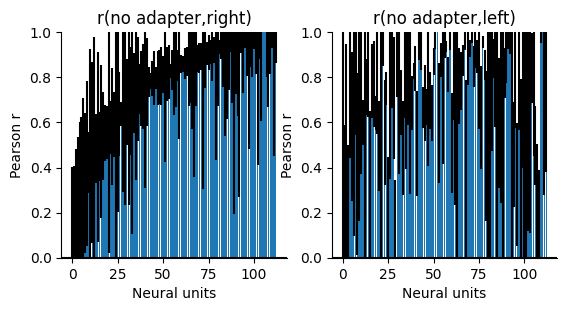

In [13]:
# plot the correlations for all the neurons we have for both R(no adapter,right) and R(no adapter,left)
fig,axs = plt.subplots(1,2)

axs[0].bar(range(len(s3_s5_r)),s3_s5_r,yerr=s3_s5_std)
axs[0].set(title='r(no adapter,right)')

axs[1].bar(range(len(s4_s5_r)),s4_s5_r,yerr=s4_s5_std)
axs[1].set(title='r(no adapter,left)')


for n in range(2):
    axs[n].axhline(y=0, color='k')
    axs[n].spines['top'].set_visible(False)
    axs[n].spines['right'].set_visible(False)
    axs[n].set(xlabel='Neural units',ylabel='Pearson r')
    axs[n].set_ylim(0,1)
    x0, x1 = axs[n].get_xlim()
    y0, y1 = axs[n].get_ylim()
    axs[n].set_aspect(abs(x1 - x0) / abs(y1 - y0), adjustable='box')

# plt.savefig('/home/eyakub/scratch/s345_corrs_bar.eps', format='eps', bbox_inches='tight')

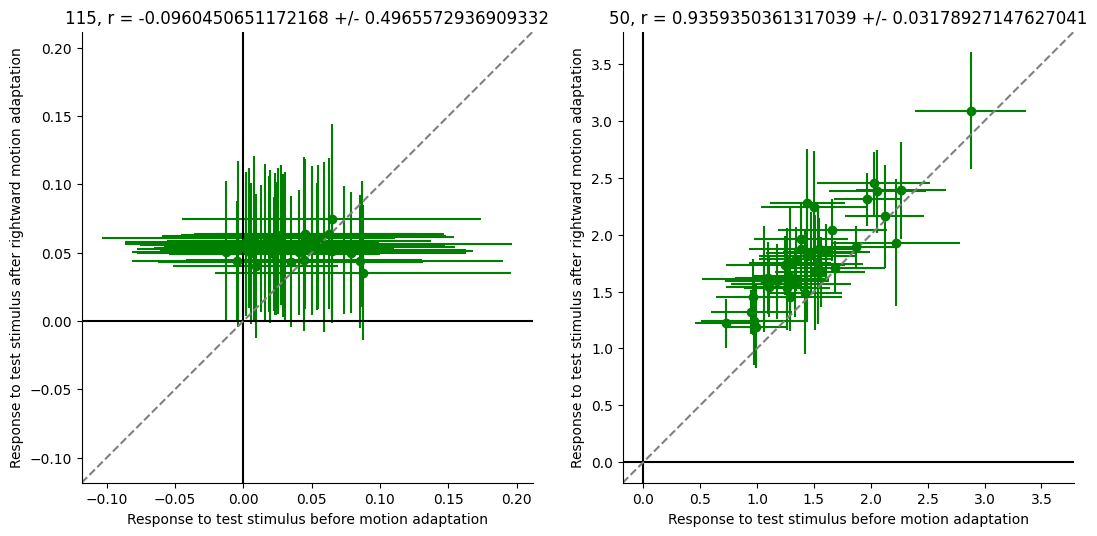

In [14]:
# plot the responses of units with largest and smallest correlations - response after right motion adaptation (s3) 
# and response before motion adaptation (s5)

fig1, axs1 = plt.subplots(nrows=1,ncols=2)
current_size = fig1.get_size_inches() 
fig1.set_size_inches(current_size[0] * 2, current_size[1] * 2.5)

small_idx = s3_s5_uncorr_sorted[0]['idx']
large_idx = s3_s5_uncorr_sorted[-1]['idx']

axs1[0].errorbar(s5_neural_mean[:,small_idx],s3_neural_mean[:,small_idx],xerr=s5_neural_std[:,small_idx],yerr=s3_neural_std[:,small_idx],fmt='o',color='green')
axs1[0].set(title=f"{small_idx}, r = {s3_s5_df.loc[s3_s5_df['idx'] == small_idx, 'r'].values[0]} +/- {s3_s5_df.loc[s3_s5_df['idx'] == small_idx, 'std'].values[0]}")

axs1[1].errorbar(s5_neural_mean[:,large_idx],s3_neural_mean[:,large_idx],xerr=s5_neural_std[:,large_idx],yerr=s3_neural_std[:,large_idx],fmt='o',color='green')
axs1[1].set(title=f"{large_idx}, r = {s3_s5_df.loc[s3_s5_df['idx'] == large_idx, 'r'].values[0]} +/- {s3_s5_df.loc[s3_s5_df['idx'] == large_idx, 'std'].values[0]}")

for n in range(2):
    axs1[n].axhline(y=0,color='k')
    axs1[n].axvline(x=0,color='k')
    
    x0, x1 = axs1[n].get_xlim()
    y0, y1 = axs1[n].get_ylim()
    
    all_min = min((x0,x1,y0,y1))
    all_max = max((x0,x1,y0,y1))
    
    axs1[n].plot((all_min,all_max),(all_min,all_max),color='grey',linestyle='--')
    
    axs1[n].set(xlabel='Response to test stimulus before motion adaptation', 
                ylabel='Response to test stimulus after rightward motion adaptation')
    
    axs1[n].set_xlim(all_min,all_max)
    axs1[n].set_ylim(all_min,all_max)
    
    axs1[n].spines['top'].set_visible(False)
    axs1[n].spines['right'].set_visible(False)
    # axs[m].label_outer()
    axs1[n].set_aspect(abs(all_max - all_min) / abs(all_max - all_min))

# plt.savefig('/home/eyakub/scratch/corr_s3_s5.eps', format='eps', bbox_inches='tight')

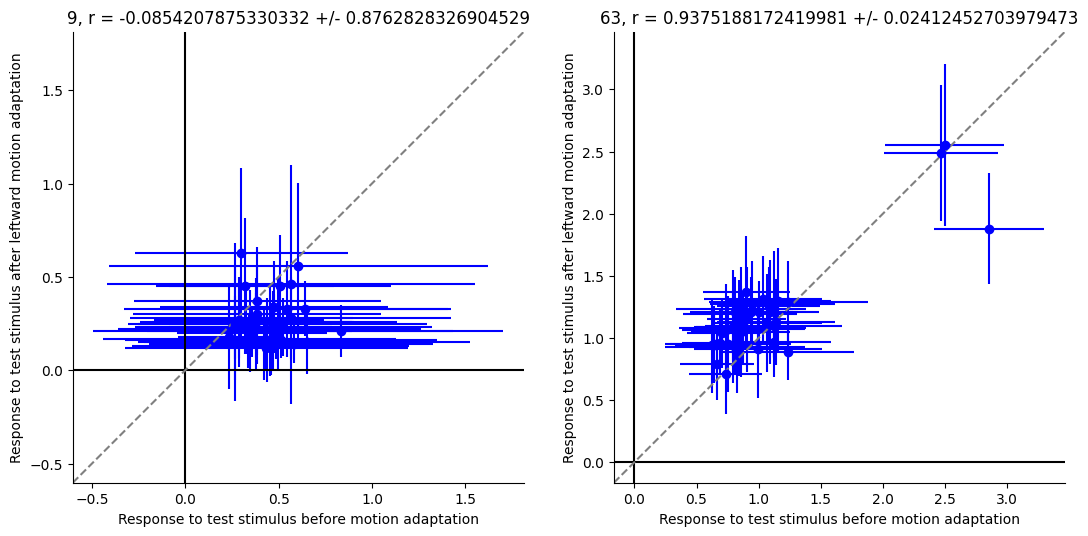

In [15]:
# plot the responses of units with largest and smallest correlations - response after left motion adaptation (s4) 
# and response before motion adaptation (s5)

fig2, axs2 = plt.subplots(nrows=1,ncols=2)
current_size = fig2.get_size_inches() 
fig2.set_size_inches(current_size[0] * 2, current_size[1] * 2.5)

small_idx = s4_s5_uncorr_sorted[0]['idx']
large_idx = s4_s5_uncorr_sorted[-1]['idx']

axs2[0].errorbar(s5_neural_mean[:,small_idx],s4_neural_mean[:,small_idx],xerr=s5_neural_std[:,small_idx],yerr=s4_neural_std[:,small_idx],fmt='o',color='blue')
axs2[0].set(title=f"{small_idx}, r = {s4_s5_df.loc[s4_s5_df['idx'] == small_idx, 'r'].values[0]} +/- {s4_s5_df.loc[s4_s5_df['idx'] == small_idx, 'std'].values[0]}")

axs2[1].errorbar(s5_neural_mean[:,large_idx],s4_neural_mean[:,large_idx],xerr=s5_neural_std[:,large_idx],yerr=s4_neural_std[:,large_idx],fmt='o',color='blue')
axs2[1].set(title=f"{large_idx}, r = {s4_s5_df.loc[s4_s5_df['idx'] == large_idx, 'r'].values[0]} +/- {s4_s5_df.loc[s4_s5_df['idx'] == large_idx, 'std'].values[0]}")

for n in range(2):
    axs2[n].axhline(y=0,color='k')
    axs2[n].axvline(x=0,color='k')
    
    x0, x1 = axs2[n].get_xlim()
    y0, y1 = axs2[n].get_ylim()
    
    all_min = min((x0,x1,y0,y1))
    all_max = max((x0,x1,y0,y1))
    
    axs2[n].plot((all_min,all_max),(all_min,all_max),color='grey',linestyle='--')

    axs2[n].set(xlabel='Response to test stimulus before motion adaptation', 
                ylabel='Response to test stimulus after leftward motion adaptation')
    
    axs2[n].set_xlim(all_min,all_max)
    axs2[n].set_ylim(all_min,all_max)
    
    axs2[n].spines['top'].set_visible(False)
    axs2[n].spines['right'].set_visible(False)
    # axs[m].label_outer()
    axs2[n].set_aspect(abs(all_max - all_min) / abs(all_max - all_min))

# plt.savefig('/home/eyakub/scratch/corr_s4_s5.eps', format='eps', bbox_inches='tight')

Figure 3 C

In [16]:
def unbiased_HSIC(K, L):
  '''Computes an unbiased estimator of HISC. This is equation (3) from the paper Nguyen et al., arXiv, 2021'''

  #create the unit **vector** filled with ones
  n = K.shape[0]
  ones = np.ones(shape=(n))

  #fill the diagonal entries with zeros 
  np.fill_diagonal(K, val=0) #this is now K_tilde 
  np.fill_diagonal(L, val=0) #this is now L_tilde

  #first part in the square brackets
  trace = np.trace(np.dot(K, L))

  #middle part in the square brackets
  nominator1 = np.dot(np.dot(ones.T, K), ones)
  nominator2 = np.dot(np.dot(ones.T, L), ones)
  denominator = (n-1)*(n-2)
  middle = np.dot(nominator1, nominator2) / denominator
  
  
  #third part in the square brackets
  multiplier1 = 2/(n-2)
  multiplier2 = np.dot(np.dot(ones.T, K), np.dot(L, ones))
  last = multiplier1 * multiplier2

  #complete equation
  unbiased_hsic = 1/(n*(n-3)) * (trace + middle - last)

  return unbiased_hsic

In [17]:
def CKA(X, Y):
  '''Computes the CKA of two matrices. This is equation (1) from the paper Nguyen et al., arXiv, 2021'''
  
  nominator = unbiased_HSIC(np.dot(X, X.T), np.dot(Y, Y.T))
  denominator1 = unbiased_HSIC(np.dot(X, X.T), np.dot(X, X.T))
  denominator2 = unbiased_HSIC(np.dot(Y, Y.T), np.dot(Y, Y.T))

  cka = nominator/np.sqrt(denominator1*denominator2)

  return cka

In [18]:
def calculate_CKA_for_two_matrices(activationA, activationB):
  '''Takes two activations A and B and computes the linear CKA to measure their similarity'''

  #unfold the activations, that is make a (n, h*w*c) representation
  shape = activationA.shape
  activationA = np.reshape(activationA, newshape=(shape[0], np.prod(shape[1:])))

  shape = activationB.shape
  activationB = np.reshape(activationB, newshape=(shape[0], np.prod(shape[1:])))

  #calculate the CKA score
  cka_score = CKA(activationA, activationB)

  del activationA
  del activationB

  return cka_score

In [19]:
# Load the data 
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5', 'r') as f:
    r1 = f['/psth'][:]
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5', 'r') as f:
    r2 = f['/psth'][:]
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5', 'r') as f:
    r0 = f['/psth'][:]

print(r1.shape)
print(r2.shape)
print(r0.shape)

# Permute the axes of the arrays to match MATLAB's permute function
# Note: MATLAB's indexing starts at 1, whereas Python's starts at 0

r1 = np.transpose(r1, (1, 3, 0, 2))
r2 = np.transpose(r2, (1, 3, 0, 2))
r0 = np.transpose(r0, (1, 3, 0, 2))

# Print the sizes of the arrays

print(r1.shape)
print(r2.shape)
print(r0.shape)

(40, 10, 410, 192)
(40, 10, 410, 192)
(40, 36, 30, 192)
(10, 192, 40, 410)
(10, 192, 40, 410)
(36, 192, 40, 30)


In [20]:
# Load the metadata 
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5', 'r') as f:
    tStart = f['/meta/start_time_ms'][()]
    bin = f['/meta/tb_ms'][()]
    tStop = f['/meta/stop_time_ms'][()]

# Adjust tStop to ensure inclusivity or the correct size, if necessary
# Example adjustment, might need fine-tuning based on actual values
adjusted_tStop = tStop - bin + 1  # +1 for inclusivity, if necessary

# Create the time array
time = np.arange(tStart, adjusted_tStop, bin) - 3200

# Ensure the size of the time array is 410, adjust as necessary
if len(time) != 410:
    # Adjust your range or logic based on actual start/stop values and requirements
    print(f"Current size is {len(time)}, which does not match the expected 410. Adjusting the logic might be necessary.")

# Print the size of the time array
print(time.shape)

(410,)


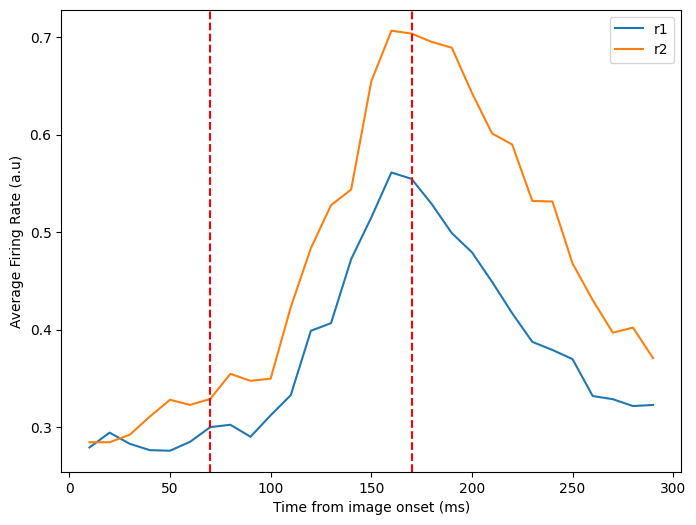

In [21]:
# Assuming 'time' and 'r1', 'r2' arrays are already defined as per previous steps

# Time conditions
time_condition = (time > 0) & (time < 300)

# Calculate the mean across the specified dimensions ignoring NaNs for r1 and r2
# For r1
mean_r1 = np.nanmean(np.nanmean(np.nanmean(r1[:, :, :, time_condition], axis=0), axis=0), axis=0)
# For r2
mean_r2 = np.nanmean(np.nanmean(np.nanmean(r2[:, :, :, time_condition], axis=0), axis=0), axis=0)

# Plotting
plt.figure(figsize=(8, 6))  # Adjust the figure size as necessary
plt.plot(time[time_condition], mean_r1, label='r1')
plt.plot(time[time_condition], mean_r2, label='r2')

# If you need to replicate the 'journalFigure' aesthetics:
plt.xlabel('Time from image onset (ms)')
plt.ylabel('Average Firing Rate (a.u)')
plt.legend()

# Uncomment the following lines if you need to add the red dashed lines
plt.axvline(x=70, color='r', linestyle='--')
plt.axvline(x=170, color='r', linestyle='--')

# journal_figure(do_save=False, filename='my_publication_figure.eps')
plt.show()

In [22]:
# reduce the dimensionality of r0 now that it is temporally aligned 
r0 = np.nanmean(r0[:,:,:,7:18],axis=3)
r0.shape

/tmp/ipykernel_1170325/2322556013.py:2: RuntimeWarning: Mean of empty slice
  r0 = np.nanmean(r0[:,:,:,7:18],axis=3)


(36, 192, 40)

In [23]:
# add Kenny's data to r0
with h5py.File('../data/neural/m2_season5.mat','r') as f:
    k0 = f['/rates'][:]
k0 = np.transpose(k0, (2,1,0))
r0 = np.concatenate((r0,k0),axis=1)
r0.shape

(36, 238, 40)

In [24]:
# use reliability filtering to ensure that only reliable neurons are included in the subsequent processing 
r0 = np.transpose(r0,(2,1,0))
rel = neuron_reliability(r0)[0]

# for the reliable neurons, figure out the threshold for 25 percentile reliability 
thresh = np.percentile(rel[rel>0.2], 25)
print(thresh)

# filter to only include those
r0 = reliability_filtering(r0,rel,metric=thresh)

print(r0.shape)

0.6243355183628542
(40, 89, 36)


In [25]:
# reshape r0 back to its original form
r0 = np.transpose(r0,(2,1,0))

In [26]:
# compute the internal consistency
intcon = []
for i in range(10):
    l1 = np.random.choice(range(36), 4, replace=False)
    l2 = np.setdiff1d(range(36), l1)
    x1_sh1 = zscore(np.nanmean(r0[l1, :, :], axis=0),axis=1)  # Adjusted indices for Python's 0-based indexing
    # print(x1_sh1.shape)
    x1_sh2 = zscore(np.nanmean(r0[l2, :, :], axis=0),axis=1)
    temp_val = calculate_CKA_for_two_matrices(x1_sh1, x1_sh2)
    # print(temp_val)
    intcon.append(temp_val)

print(np.nanmean(intcon))

0.7684722691604351


In [27]:
# Assuming `r1`, `r2`, `r0`, and `time` are already loaded and preprocessed as per previous steps

# Conditions for selecting time intervals
time_condition = (time >= 70) & (time <= 170)

# Calculating average rates for each dataset
# Adjusting for Python's 0-based indexing and ensuring proper handling of NaN values
avg_rates_s3 = np.nanmean(np.nanmean(r1[0:8, :, :, time_condition], axis=0), axis=2) #bc the last two trials are all Nans
avg_rates_s4 = np.nanmean(np.nanmean(r2[0:8, :, :, time_condition], axis=0), axis=2)
avg_rates_s5 = np.nanmean(r0, axis=0)

# Print the shapes of the resulting arrays
print(avg_rates_s3.shape)
print(avg_rates_s4.shape)
print(avg_rates_s5.shape)

(192, 40)
(192, 40)
(89, 40)


In [28]:
# load Kenny's data 
with h5py.File('../data/neural/m2_season3.mat','r') as f:
    k1 = f['/kenny_s3'][:]
with h5py.File('../data/neural/m2_season4.mat','r') as f:
    k2 = f['/kenny_s4'][:]

print(k1.shape)
print(k2.shape)

(40, 46, 10)
(40, 46, 10)


In [29]:
# take the mean across trials and switch the axes to get it in the same order as Pico's data
k1 = np.transpose(np.nanmean(k1, axis=-1))
k2 = np.transpose(np.nanmean(k2, axis=-1))

print(k1.shape)
print(k2.shape)

(46, 40)
(46, 40)


In [30]:
# concatenate and filter Pico and Kenny's data
avg_rates_s3 = np.transpose(np.concatenate((avg_rates_s3,k1),axis=0))
avg_rates_s4 = np.transpose(np.concatenate((avg_rates_s4,k2),axis=0))

avg_rates_s3 = np.transpose(reliability_filtering(avg_rates_s3,rel,metric=thresh,trials=False))
avg_rates_s4 = np.transpose(reliability_filtering(avg_rates_s4,rel,metric=thresh,trials=False))

In [31]:
# Initialize lists to store the CKA values for each iteration
val_s3 = []
val_s4 = []
s3_s4 = []

for i in range(50):
    # Randomly sample 40 indices with replacement
    im = np.random.choice(40, 40, replace=True)
    
    # Apply the condition filter 'ic > 0' and use the sampled indices 'im'
    # Note: Ensure 'ic' is defined and correctly sized for this operation
    filtered_indices = np.ravel(np.ones((89, 1), dtype=bool)) # choosing all sites, changed to match the current number of sites
    avg_rates_s3_filtered = zscore(avg_rates_s3[filtered_indices][:, im],axis=1)
    avg_rates_s4_filtered = zscore(avg_rates_s4[filtered_indices][:, im],axis=1)
    avg_rates_s5_filtered = zscore(avg_rates_s5[filtered_indices][:, im],axis=1)
    
    # Compute CKA between the filtered and shuffled avg_rates for s3 vs. s5, and s4 vs. s5
    val_s3.append(calculate_CKA_for_two_matrices(avg_rates_s3_filtered, avg_rates_s5_filtered))
    val_s4.append(calculate_CKA_for_two_matrices(avg_rates_s4_filtered, avg_rates_s5_filtered))
    s3_s4.append(calculate_CKA_for_two_matrices(avg_rates_s3_filtered, avg_rates_s4_filtered))

# If needed, convert lists to numpy arrays for further processing or analysis
val_s3 = np.array(val_s3)
val_s4 = np.array(val_s4)
s3_s4 = np.array(s3_s4)

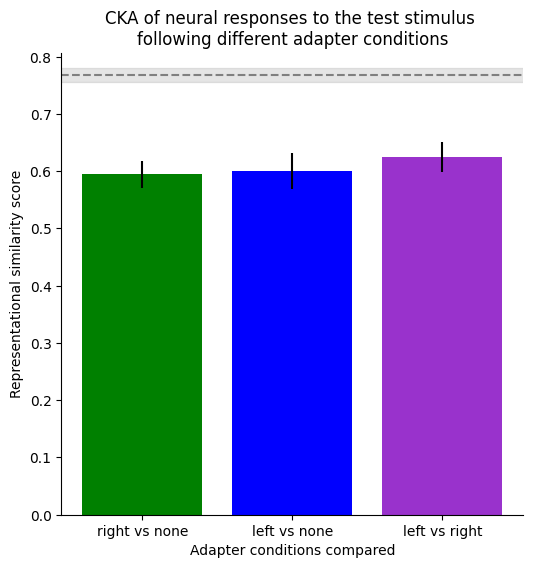

In [32]:
# Assuming intcon, val_s3, and val_s4 are already defined and filled with your data

means = [np.nanmean(intcon), np.nanmean(val_s3), np.nanmean(val_s4), np.nanmean(s3_s4)]
errors = [np.nanmedian(np.abs(intcon - np.nanmedian(intcon))), 
          np.nanmedian(np.abs(val_s3 - np.nanmedian(val_s3))), 
          np.nanmedian(np.abs(val_s4 - np.nanmedian(val_s4))),
         np.nanmedian(np.abs(s3_s4 - np.nanmedian(s3_s4)))]

# Create the error bar plot
plt.figure(figsize=(8, 6))
plt.bar(['right vs none', 'left vs none', 'left vs right'],
       [means[1],means[2],means[3]],
       yerr=[errors[1],errors[2],errors[3]],
       color=['green','blue','darkorchid'])
plt.xlabel('Adapter conditions compared')
plt.ylabel('Representational similarity score')
plt.title('CKA of neural responses to the test stimulus \nfollowing different adapter conditions')

plt.axhline(y=means[0], color = 'grey',linestyle='--') # internal consistency of responses to the test stimulus across trials without adaptation
rectangle = Rectangle((-1,means[0]-errors[0]), 6, 2*errors[0], color='grey', alpha=0.2)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().set_aspect(1.0/plt.gca().get_data_ratio(), adjustable='box')

plt.gca().add_patch(rectangle)

# plt.savefig("/home/eyakub/scratch/cka_s3_s4.eps", format="eps", bbox_inches="tight")

Figure 3 D

In [33]:
# import data files from Pico and Kenny
p_file = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')
k_file = h5py.File('../data/neural/m2_season5.mat','r')

p_rates = p_file['/psth'][:]
k_rates = k_file['/rates'][:]

In [34]:
# load the ground truth center positions in pixel space 
human_im_size = 268.51895786308
gt_im_size = 256
df = pd.read_csv('../data/mae_s5_coordinates.csv') # position data
pos = np.squeeze(df['center_x'].values.reshape(-1,1))*(human_im_size/gt_im_size) # convert to the dimensions of the image that the humans made estimates on

# convert labels to eccentricity 
pos = convert_to_deg(pos, human_im_size)

In [35]:
# getting 70-170 ms and reshaping for S5 Pico and Kenny
s5_neural_pico = np.transpose(np.nanmean(p_rates[:,:,7:17,:],axis=2), (0,2,1)) # gets the neural data for 70-170 ms only, raised a mean of an empty slice warning bc last couple of reps are empty
s5_neural_kenny = k_rates

/tmp/ipykernel_1170325/3951971199.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_pico = np.transpose(np.nanmean(p_rates[:,:,7:17,:],axis=2), (0,2,1)) # gets the neural data for 70-170 ms only, raised a mean of an empty slice warning bc last couple of reps are empty


In [36]:
# concatenate Pico and Kenny's data along the units axis
s5_neural = np.concatenate((s5_neural_pico,s5_neural_kenny), axis=1)

In [37]:
# get the neuron reliabilities for 70-170 ms
rel, std_rel = neuron_reliability(s5_neural)

In [38]:
# filter neurons to include only those with r > 0.2
s5_neural = reliability_filtering(s5_neural,rel,metric=0.2)

In [39]:
# normalize the results across all the units (axis = 1) - in the combined population because we want one distribution
s5_neural = zscore(s5_neural,axis=1)

In [40]:
# reduce dimensionality for making preds, no more repetitions
s5_neural_for_preds = np.nanmean(s5_neural,axis=2)

In [41]:
# train the decoder on s5 data 
n_img = 40
n_reps = 100
n_folds = 4
alpha_values = [0.01, 0.1, 1, 10, 100]
s5_regressors = {}
s5_reg_rels = np.empty((n_reps,n_folds))
s5_em_array= np.empty((n_img,n_reps)) # 40 images by 100 predictions per image
for x in range(n_reps):
    for i in range(n_folds):
        train, test = regression_indices(n_img, number_of_groups=4, test_group=i, SEED=x)
        x_train = s5_neural_for_preds[train,:]
        y_train = pos[train]
        x_test = s5_neural_for_preds[test,:]
        ridge_cv = RidgeCV(alphas=alpha_values).fit(x_train,y_train) # performs leave-one-out cross validated alpha optimization
        best_alpha = ridge_cv.alpha_
        s5_regressors[f"reg_{x}_{i}"] = Ridge(alpha=best_alpha) 
        s5_regressors[f"reg_{x}_{i}"].fit(x_train,y_train)
        y_pred = s5_regressors[f"reg_{x}_{i}"].predict(x_test)
        s5_em_array[test, x] = np.squeeze(y_pred)
        s5_reg_rels[x,i] = model_reliability_2(s5_neural, s5_regressors[f"reg_{x}_{i}"], test)

In [42]:
#load and format S3 and S4 for both Pico and Kenny
p_file_s3 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
p_file_s4 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')
k_file_s3 = h5py.File('../data/neural/m2_season3.mat','r')
k_file_s4 = h5py.File('../data/neural/m2_season4.mat','r')

p_rates_s3 = p_file_s3['/psth'][:]
p_rates_s4 = p_file_s4['/psth'][:]
k_rates_s3 = k_file_s3['/kenny_s3'][:]
k_rates_s4 = k_file_s4['/kenny_s4'][:]

In [43]:
# getting 70-170 ms after test stimulus onset for S1-4 for Pico and Kenny
s3_neural_pico = np.transpose(np.nanmean(p_rates_s3[:,:,337:347,:],axis=2), (0,2,1)) 
s4_neural_pico = np.transpose(np.nanmean(p_rates_s4[:,:,337:347,:],axis=2), (0,2,1)) 
s3_neural_kenny = k_rates_s3
s4_neural_kenny = k_rates_s4

In [44]:
# concatenate Pico and Kenny data along units, and filter for only reliable units 
s3_neural = reliability_filtering(np.concatenate((s3_neural_pico,s3_neural_kenny),axis=1),rel,metric=0.2)
s4_neural = reliability_filtering(np.concatenate((s4_neural_pico,s4_neural_kenny),axis=1),rel,metric=0.2)

In [45]:
# z-scoring across units 
s3_neural = zscore(s3_neural, axis=1)
s4_neural = zscore(s4_neural, axis=1)

In [46]:
# preparing the data for making predictions
s3_neural_for_preds = np.nanmean(s3_neural,axis=2)
s4_neural_for_preds = np.nanmean(s4_neural,axis=2)

In [47]:
# function for making predictions 
def seasons_preds(neural,best_rep):
    reg_rels = np.empty((n_reps,n_folds))
    season_rates = np.nanmean(neural,axis=2)
    em_array= np.empty((n_img,n_reps))
    for x in range(n_reps):
        for i in range(n_folds):
            test = regression_indices(n_img, number_of_groups=n_folds, test_group= i, SEED= x)[1] # use the function in functions.py to get the indices (i.e., the identifier of the images) in the train and test set
            X_test = season_rates[test,:] # index the neural data for the images used for testing from the neural variable
            y_pred = s5_regressors[f"reg_{x}_{i}"].predict(X_test)
            reg_rels[x,i] = model_reliability_2(neural, s5_regressors[f"reg_{x}_{i}"], test)
            em_array[test,x] = np.squeeze(y_pred)
    s_preds = np.nanmean(em_array[:,:best_rep], axis=1) # get correlation only up to the best rep
    s_preds_std = np.nanstd(em_array[:,:best_rep], axis=1)
    corr = np.empty(best_rep) 
    for p in range(best_rep): # edited to be correlation with s5 predictions
        corr_temp = pearsonr(s5_em_array[:,p], em_array[:,p])[0] # correlate the predictions from each shuffle with s5 preds
        corr[p] = corr_temp/np.sqrt(np.nanmean(reg_rels,axis=1)[p])
    s_corr = np.nanmean(corr)
    s_corr_std = np.nanstd(corr)
    return corr, s_preds, s_preds_std, s_corr, s_corr_std, em_array

In [48]:
# getting the predictions for each season
full_s3x_corr, s3_preds, s3_preds_std, s3_corr, s3_corr_std, s3_pred_array = seasons_preds(s3_neural,100)
full_s4x_corr, s4_preds, s4_preds_std, s4_corr, s4_corr_std, s4_pred_array = seasons_preds(s4_neural,100)

In [49]:
# save the correlations to use in figure 5
np.save('../data/s3xpreds_s5_corr.npy',full_s3x_corr)
np.save('../data/s4xpreds_s5_corr.npy',full_s4x_corr)

In [50]:
# plotting range
pos_range = np.linspace(min(pos),max(pos))

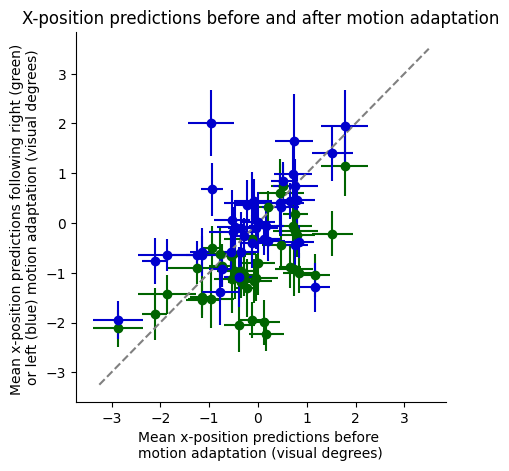

In [51]:
# s3 vs s4 predictions
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

best_rep = 100
s5_preds = np.nanmean(s5_em_array[:,:best_rep],axis=1)
s5_preds_std = np.nanstd(s5_em_array[:,:best_rep],axis=1)

plt.errorbar(s5_preds,s3_preds,xerr=s5_preds_std,yerr=s3_preds_std, fmt='o', color='darkgreen') # rightward motion
plt.errorbar(s5_preds,s4_preds,xerr=s5_preds_std,yerr=s4_preds_std, fmt='o', color='mediumblue') # leftward motion
plt.plot(pos_range,pos_range, color='grey', linestyle='--')

plt.xlabel('Mean x-position predictions before \nmotion adaptation (visual degrees)')
plt.ylabel('Mean x-position predictions following right (green) \nor left (blue) motion adaptation (visual degrees)')
plt.title('X-position predictions before and after motion adaptation')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/x_s34.eps', format='eps', bbox_inches='tight')

In [52]:
# set-up for plotting predictions on the image 
bounding_box_info = pd.read_csv('../data/mae_s5_coordinates.csv') # change this to the location of the csv
image_id = 28 # change this to the id of the image you want to visualize, apparently image 24, image 39, image 38 has the biggest delta
image_file_path = f'../data/season5/im{image_id}.png' # change this to the path of the images (with the id)

In [54]:
# convert the predictions into pixel space for plotting - to recreate the predictions for y-position, run fig3_ypreds.ipynb

def convert_to_px(deg,im_size):
    '''
    Function to convert predictions in visual degrees to pixels for plotting. 
    deg - ndarray
    im_size - int or float
    '''
    return np.array(deg*im_size/16 + im_size/2).astype(int)

s3x_px = convert_to_px(s3_pred_array, human_im_size)
s4x_px = convert_to_px(s4_pred_array, human_im_size)

s3y = np.load('../data/s3y_neural_pred_array.npy')
s4y = np.load('../data/s4y_neural_pred_array.npy')

s3y_px = convert_to_px(s3y, human_im_size)
s4y_px = convert_to_px(s4y, human_im_size)

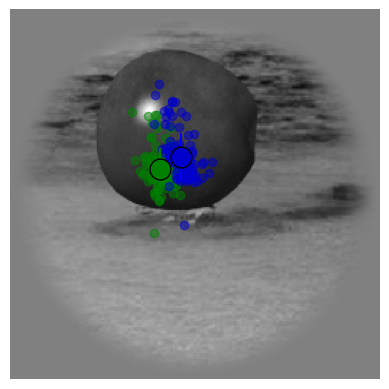

In [55]:
# load the image and the position estimates 

# Plot the image
fig, ax = plt.subplots()
img = mpimg.imread(image_file_path)

ax.imshow(img)

# Want to plot the trial-by-trial responses scaled down to the 256x256 image 
# (recall: the predictions were computed on images of slightly different size so need to scale their responses to the image size)
gt_im_size = 256
s3x_scaled = s3x_px[image_id,:]*(gt_im_size/human_im_size)
s3y_scaled = s3y_px[image_id,:]*(gt_im_size/human_im_size)
s4x_scaled = s4x_px[image_id,:]*(gt_im_size/human_im_size)
s4y_scaled = s4y_px[image_id,:]*(gt_im_size/human_im_size)

# plot all the individual estimates 
plt.scatter(s3x_scaled,s3y_scaled,color='green',alpha=0.5)
plt.scatter(s4x_scaled,s4y_scaled,color='mediumblue',alpha=0.5)

# plot the average and sem of the estimates
plt.errorbar(np.nanmean(s3x_scaled),np.nanmean(s3y_scaled),np.nanstd(s3y_scaled),np.nanstd(s3x_scaled),'go',mec='black',mfc='green',markersize=15,alpha=1)
plt.errorbar(np.nanmean(s4x_scaled),np.nanmean(s4y_scaled),np.nanstd(s4y_scaled),np.nanstd(s4x_scaled),'bo', mec='black', mfc= 'mediumblue',markersize=15,alpha=1)

plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_axis_off()

# plt.savefig('/home/eyakub/scratch/s34_neural_estimates.eps', format='eps', bbox_inches='tight')

Figure 3 E - please run Figure 3 D code before this section

In [56]:
# compute the deltas 
mean_delta = np.nanmean(s4_preds-s3_preds)
sem_delta = sem(s4_preds-s3_preds)
std_delta = np.nanstd(np.nanmean(s4_pred_array-s3_pred_array,axis=0))

print(f"mean delta s4 vs s3: {mean_delta} +/- {std_delta}")

mean delta s4 vs s3: 0.8412620639119179 +/- 0.056583974470074266


In [57]:
# store the deltas for use in figure 5 
np.save('../data/pixel_space_neurals34_deltax.npy', s4_preds-s3_preds)

In [58]:
# check whether assumptions violated for deltas 
print(f"s4-s3: {check_normality('singlet',s4_preds-s3_preds)}")

s4-s3: 0.09539783000946045


In [59]:
# assumptions not violated 
print(f"s4-s3: {ttest_1samp(s4_preds-s3_preds,0)}")

s4-s3: TtestResult(statistic=6.245833490964673, pvalue=2.359686279348493e-07, df=39)


In [60]:
# load the human deltas - you can recompute these using figure2.ipynb
with open('../data/human_deltax_dict.pkl', 'rb') as f:
    human_deltax_dict = pickle.load(f)

human_deltax_dict.keys()

dict_keys(['s4_v_s3', 's3_v_s5', 's4_v_s5'])

In [61]:
# load and compile the deltas across the number of neurons - you can recompute these using fig3_deltas.sh
d43x_1050 = np.load('../data/ds43x_10-50_ecc_reps.npy')
d43x_60110 = np.load('../data/ds43x_60-110_ecc_reps.npy')
d43x_on = np.concatenate((d43x_1050,d43x_60110),axis=0)

In [62]:
# test whether the human and neural deltas are significantly different across subsamples of neurons 
s43_hvon = []

for i in range(d43x_on.shape[0]):
    s43_hvon.append(ttest_ind(human_deltax_dict['s4_v_s3'],d43x_on[i]).pvalue)

In [63]:
# test the human and final neural deltas 
print(f"s4 vs s3: {ttest_ind(human_deltax_dict['s4_v_s3'],s4_preds-s3_preds)}")

s4 vs s3: TtestResult(statistic=-3.6559353065436633, pvalue=0.0004630353092723262, df=78.0)


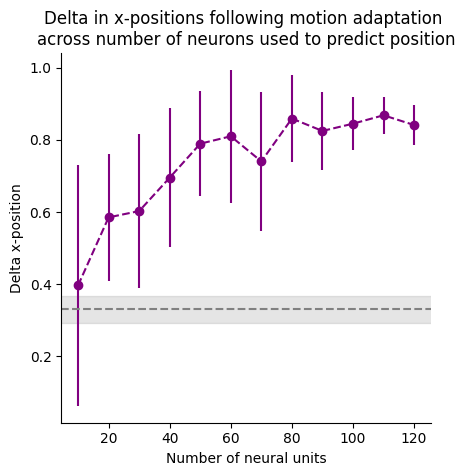

In [64]:
# plot deltas across number of neural units used
mean_d43_on = np.nanmean(np.nanmean(d43x_on,axis=-1),axis=1)
std_d43_on = np.nanstd(np.nanmean(d43x_on,axis=-1),axis=1)
plot_d43 = np.concatenate((mean_d43_on, np.array([mean_delta])))
std_d43 = np.concatenate((std_d43_on, np.array([std_delta])))
plt_range = np.arange(10,130,10)

plt.errorbar(plt_range, plot_d43, yerr=std_d43, linestyle='--', marker='o', color='purple')
plt.axhline(np.nanmean(human_deltax_dict['s4_v_s3']), linestyle='--', color='grey')
rectangle4 = Rectangle((0,np.nanmean(human_deltax_dict['s4_v_s3'])-sem(human_deltax_dict['s4_v_s3'])),130,2*sem(human_deltax_dict['s4_v_s3']),color='grey',alpha=0.2)
plt.gca().add_patch(rectangle4)

plt.xlabel('Number of neural units')
plt.ylabel('Delta x-position')
plt.title('Delta in x-positions following motion adaptation \nacross number of neurons used to predict position')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.ylim(0,0.5)
x0, x1 = plt.gca().get_xlim()
y0, y1 = plt.gca().get_ylim()
plt.gca().set_aspect(abs(x1 - x0) / abs(y1 - y0))

# plt.savefig('/home/eyakub/scratch/d43_neural_dx_over_neurons.eps', format='eps', bbox_inches='tight')